# European Energy Analytics Pipeline — Exploratory Data Analysis

## Central research question

**How has the transition toward renewable electricity affected carbon intensity across Italy, Germany, France, Spain and the Netherlands since 2015?**

## Supporting questions

1. How have renewable, fossil and nuclear electricity shares changed over time?
2. Which countries achieved the largest reduction in carbon intensity?
3. Is higher renewable generation associated with lower carbon intensity?
4. Is fossil-fuel dependence associated with higher carbon intensity and emissions?
5. How does the relationship between electricity mix and carbon intensity differ by country?
6. What seasonal patterns exist in electricity demand, generation and carbon intensity?
7. Which countries depend most on electricity imports, and when do they become net exporters?

## Data source

The analysis uses the tested `fct_country_monthly_energy` analytical mart created with dbt and stored in DuckDB.

The dataset contains monthly observations for five European countries, primarily covering January 2015 to July 2026.

## 1. Setup and data loading

This section imports the analysis tools and loads the tested country-month energy mart from DuckDB.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts clean and consistent
sns.set_theme(style="whitegrid")

# Locate the project folder and DuckDB database
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

db_path = project_root / "data" / "warehouse" / "energy_analytics.duckdb"

print("Database path:", db_path)
print("Database found:", db_path.exists())

Database path: c:\Users\fizan\Documents\european-energy-analytics-pipeline\data\warehouse\energy_analytics.duckdb
Database found: True


In [2]:
connection = duckdb.connect(str(db_path), read_only=True)

query = """
select *
from main_marts.fct_country_monthly_energy
order by country_code, month
"""

energy = connection.execute(query).df()
connection.close()

print("Dataset shape:", energy.shape)
display(energy.head())

Dataset shape: (683, 20)


,country_name,country_code,month,demand_twh,renewable_generation_twh,fossil_generation_twh,nuclear_generation_twh,net_imports_twh,domestic_generation_twh,electricity_supply_twh,renewable_emissions_mtco2,fossil_emissions_mtco2,nuclear_emissions_mtco2,total_emissions_mtco2,carbon_intensity_gco2_per_kwh,renewable_share_pct,fossil_share_pct,nuclear_share_pct,net_import_dependence_pct,supply_demand_gap_twh
0,Germany,DEU,2015-01-01,51.87,15.65,29.44,8.74,-1.96,53.83,51.87,1.06,26.81,0.04,27.91,518.65,29.073008,54.690693,16.236299,-3.778677,7.105427e-15
1,Germany,DEU,2015-02-01,45.83,11.59,31.09,7.95,-4.80,50.63,45.83,0.96,28.05,0.04,29.05,573.65,22.891566,61.406281,15.702153,-10.473489,0.000000e+00
2,Germany,DEU,2015-03-01,47.19,15.75,29.49,7.69,-5.74,52.93,47.19,1.15,27.02,0.04,28.21,532.93,29.756282,55.715095,14.528623,-12.163594,0.000000e+00
3,Germany,DEU,2015-04-01,42.55,15.60,23.65,7.25,-3.95,46.50,42.55,1.20,22.20,0.04,23.44,503.68,33.548387,50.860215,15.591398,-9.283196,0.000000e+00
4,Germany,DEU,2015-05-01,42.12,16.25,19.77,7.43,-1.33,43.45,42.12,1.23,18.22,0.04,19.49,448.58,37.399310,45.500575,17.100115,-3.157645,7.105427e-15


## 2. Initial dataset inspection

Before analysing trends, we inspect the dataset structure, variable types and missing values.

In [3]:
energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   country_name                   683 non-null    str           
 1   country_code                   683 non-null    str           
 2   month                          683 non-null    datetime64[us]
 3   demand_twh                     683 non-null    float64       
 4   renewable_generation_twh       683 non-null    float64       
 5   fossil_generation_twh          683 non-null    float64       
 6   nuclear_generation_twh         683 non-null    float64       
 7   net_imports_twh                683 non-null    float64       
 8   domestic_generation_twh        683 non-null    float64       
 9   electricity_supply_twh         683 non-null    float64       
 10  renewable_emissions_mtco2      682 non-null    float64       
 11  fossil_emissions_mtco2        

### Missing-value review

The mart contains one country-month with unavailable emissions data. We identify it before continuing and retain the row because its demand, generation and carbon-intensity measurements remain valid.

In [4]:
emissions_missing = energy.loc[
    energy["total_emissions_mtco2"].isna(),
    [
        "country_name",
        "country_code",
        "month",
        "renewable_emissions_mtco2",
        "fossil_emissions_mtco2",
        "nuclear_emissions_mtco2",
        "total_emissions_mtco2"
    ]
]

display(emissions_missing)

,country_name,country_code,month,renewable_emissions_mtco2,fossil_emissions_mtco2,nuclear_emissions_mtco2,total_emissions_mtco2
543,Italy,ITA,2026-07-01,NaN,NaN,NaN,NaN


### Country and time coverage

We inspect the number of monthly observations and the available date range for each country. This helps ensure that later cross-country comparisons use compatible periods.

In [5]:
country_coverage = (
    energy.groupby(["country_name", "country_code"])
    .agg(
        observations=("month", "size"),
        first_month=("month", "min"),
        last_month=("month", "max")
    )
    .reset_index()
)

display(country_coverage)

,country_name,country_code,observations,first_month,last_month
0,France,FRA,139,2015-01-01,2026-07-01
1,Germany,DEU,139,2015-01-01,2026-07-01
2,Italy,ITA,127,2016-01-01,2026-07-01
3,Netherlands,NLD,139,2015-01-01,2026-07-01
4,Spain,ESP,139,2015-01-01,2026-07-01


### Comparable analysis period

Italy's observations begin in January 2016, while the other countries begin in January 2015. Therefore, cross-country comparisons use January 2016 onward. The complete dataset remains available for individual country trend analysis.

In [6]:
comparison_data = energy.loc[
    energy["month"] >= "2016-01-01"
].copy()

print("Complete dataset:", energy.shape)
print("Comparable dataset:", comparison_data.shape)

Complete dataset: (683, 20)
Comparable dataset: (635, 20)


## 3. Descriptive overview by country

We first compare the average electricity-system characteristics of the five countries over the common January 2016–July 2026 period.

In [7]:
country_summary = (
    comparison_data.groupby("country_name", as_index=False)
    .agg(
        average_demand_twh=("demand_twh", "mean"),
        average_renewable_share_pct=("renewable_share_pct", "mean"),
        average_fossil_share_pct=("fossil_share_pct", "mean"),
        average_nuclear_share_pct=("nuclear_share_pct", "mean"),
        average_carbon_intensity=("carbon_intensity_gco2_per_kwh", "mean"),
        average_net_import_dependence_pct=("net_import_dependence_pct", "mean")
    )
    .round(2)
    .sort_values("average_renewable_share_pct", ascending=False)
)

display(country_summary)

,country_name,average_demand_twh,average_renewable_share_pct,average_fossil_share_pct,average_nuclear_share_pct,average_carbon_intensity,average_net_import_dependence_pct
4,Spain,20.54,47.76,30.37,21.88,207.05,-1.12
1,Germany,43.39,46.22,46.16,7.62,409.21,-3.27
2,Italy,25.58,43.40,56.60,0.00,344.13,14.00
3,Netherlands,10.01,34.80,62.28,2.92,373.08,-1.70
0,France,37.72,22.10,7.36,70.54,49.74,-12.30


### Average electricity mix

A 100% stacked bar chart compares the average renewable, fossil and nuclear generation shares of each country.

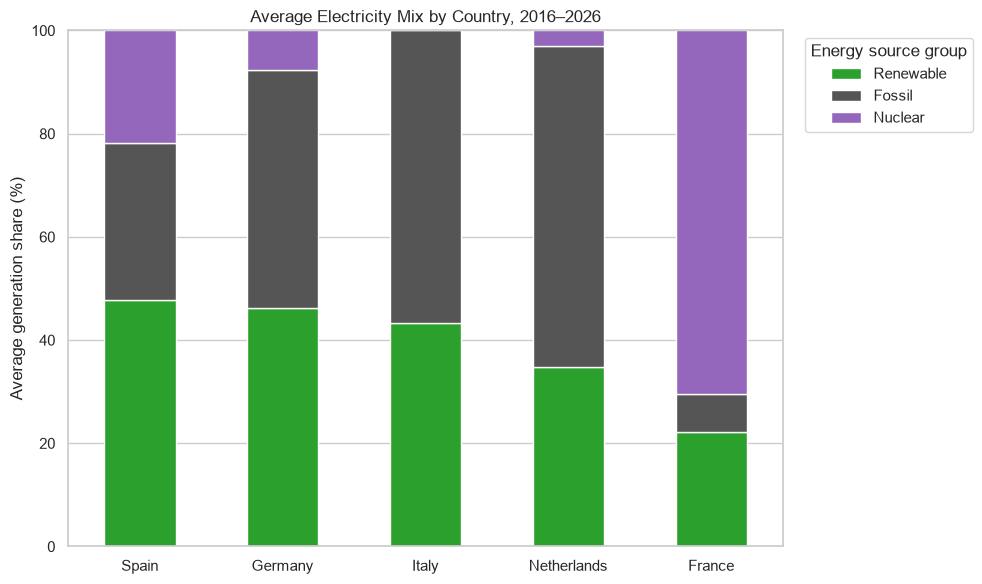

In [8]:
electricity_mix = (
    country_summary
    .set_index("country_name")[
        [
            "average_renewable_share_pct",
            "average_fossil_share_pct",
            "average_nuclear_share_pct"
        ]
    ]
)

electricity_mix.columns = ["Renewable", "Fossil", "Nuclear"]

ax = electricity_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#2ca02c", "#555555", "#9467bd"]
)

ax.set_title("Average Electricity Mix by Country, 2016–2026")
ax.set_xlabel("")
ax.set_ylabel("Average generation share (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(title="Energy source group", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 4. Electricity transition over time

### Renewable electricity trend

Monthly electricity shares can fluctuate because of weather and seasonality. A 12-month rolling average is used to reveal the underlying long-term renewable transition.

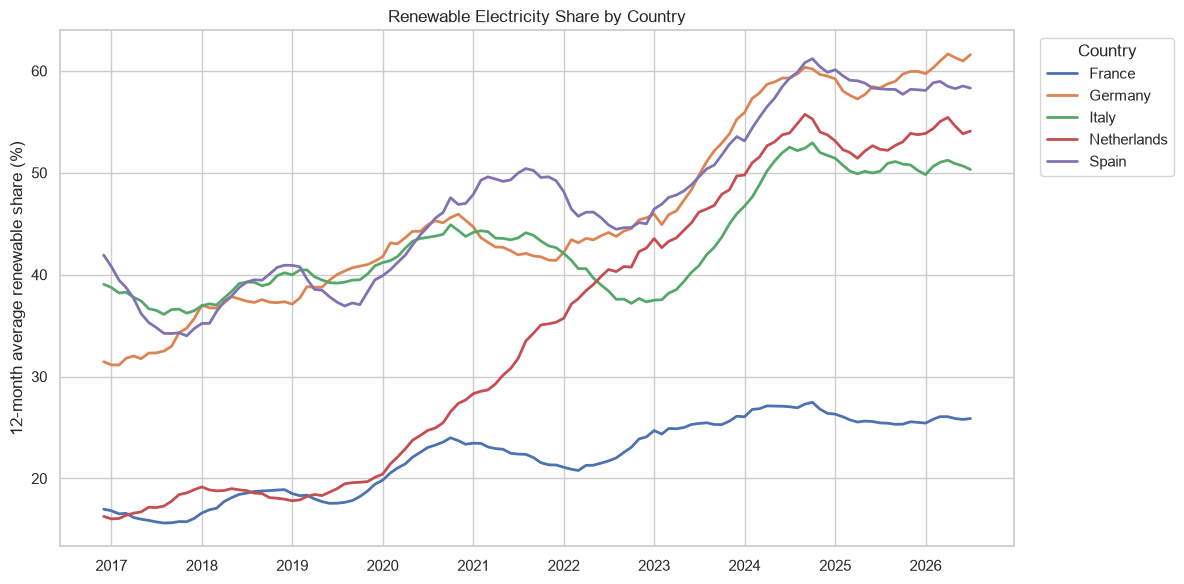

In [9]:
comparison_data = comparison_data.sort_values(
    ["country_name", "month"]
).copy()

comparison_data["renewable_share_12m_avg"] = (
    comparison_data.groupby("country_name")["renewable_share_pct"]
    .transform(
        lambda values: values.rolling(
            window=12,
            min_periods=12
        ).mean()
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=comparison_data,
    x="month",
    y="renewable_share_12m_avg",
    hue="country_name",
    linewidth=2
)

plt.title("Renewable Electricity Share by Country")
plt.xlabel("")
plt.ylabel("12-month average renewable share (%)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

#### Initial findings

- Renewable electricity share increased across all five countries.
- The Netherlands experienced the largest relative transition, rising from approximately 16% to above 50%.
- Germany and Spain reached renewable shares close to 60% by the end of the period.
- Italy showed a more moderate increase, reaching approximately 50%.
- France's renewable share remained comparatively low, but its electricity system relies heavily on low-carbon nuclear generation.
- These patterns describe changes over time but do not, by themselves, establish causation.

### Carbon-intensity trend

We now examine whether the renewable transition occurred alongside declining carbon intensity. The same 12-month rolling window is used to remove short-term seasonal fluctuations.

C:\Users\fizan\AppData\Local\Temp\ipykernel_30940\1863105009.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\fizan\Documents\european-energy-analytics-pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


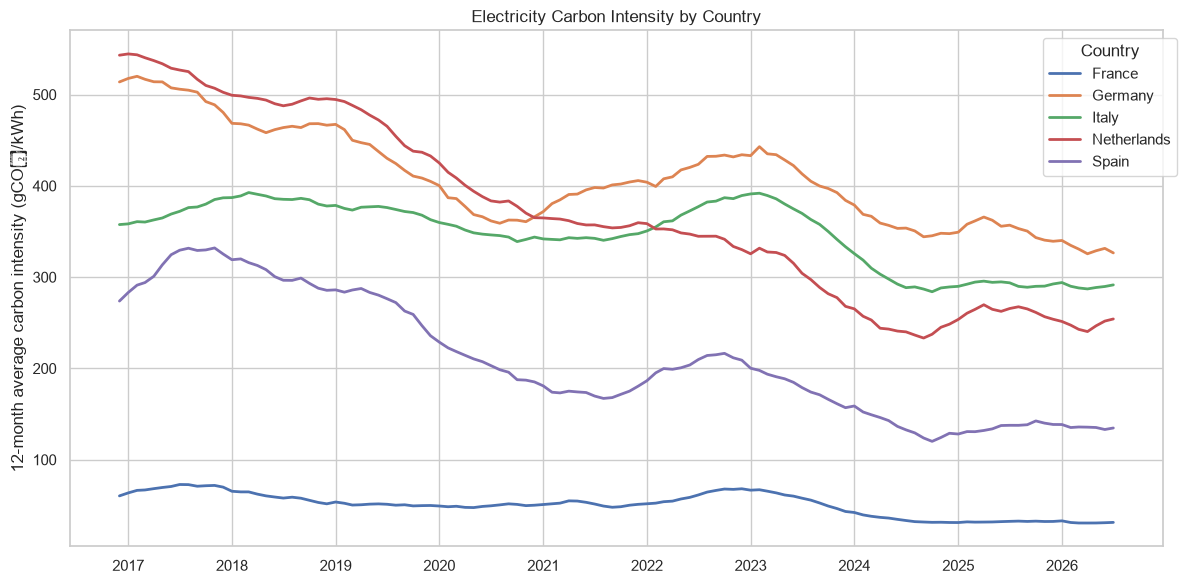

In [10]:
comparison_data["carbon_intensity_12m_avg"] = (
    comparison_data.groupby("country_name")[
        "carbon_intensity_gco2_per_kwh"
    ]
    .transform(
        lambda values: values.rolling(
            window=12,
            min_periods=12
        ).mean()
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=comparison_data,
    x="month",
    y="carbon_intensity_12m_avg",
    hue="country_name",
    linewidth=2
)

plt.title("Electricity Carbon Intensity by Country")
plt.xlabel("")
plt.ylabel("12-month average carbon intensity (gCO₂/kWh)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### Quantifying the energy transition

To move beyond visual interpretation, we compare the first and latest available 12-month averages. Renewable-share change is reported in percentage points, while carbon-intensity reduction is reported as a relative percentage.

In [11]:
trend_data = (
    comparison_data
    .dropna(
        subset=[
            "renewable_share_12m_avg",
            "carbon_intensity_12m_avg"
        ]
    )
    .sort_values(["country_name", "month"])
)

transition_summary = (
    trend_data.groupby("country_name", as_index=False)
    .agg(
        start_month=("month", "first"),
        end_month=("month", "last"),
        renewable_share_start=("renewable_share_12m_avg", "first"),
        renewable_share_end=("renewable_share_12m_avg", "last"),
        carbon_intensity_start=("carbon_intensity_12m_avg", "first"),
        carbon_intensity_end=("carbon_intensity_12m_avg", "last")
    )
)

transition_summary["renewable_change_pp"] = (
    transition_summary["renewable_share_end"]
    - transition_summary["renewable_share_start"]
)

transition_summary["carbon_intensity_reduction_pct"] = (
    (
        transition_summary["carbon_intensity_start"]
        - transition_summary["carbon_intensity_end"]
    )
    / transition_summary["carbon_intensity_start"]
    * 100
)

numeric_columns = transition_summary.select_dtypes(
    include="number"
).columns

transition_summary[numeric_columns] = (
    transition_summary[numeric_columns].round(2)
)

transition_summary = transition_summary.sort_values(
    "carbon_intensity_reduction_pct",
    ascending=False
)

display(transition_summary)

,country_name,start_month,end_month,renewable_share_start,renewable_share_end,carbon_intensity_start,carbon_intensity_end,renewable_change_pp,carbon_intensity_reduction_pct
3,Netherlands,2016-12-01,2026-07-01,16.27,54.09,543.11,254.18,37.82,53.20
4,Spain,2016-12-01,2026-07-01,41.93,58.30,273.78,134.75,16.38,50.78
0,France,2016-12-01,2026-07-01,16.98,25.88,60.36,31.33,8.90,48.10
1,Germany,2016-12-01,2026-07-01,31.46,61.59,513.82,326.54,30.13,36.45
2,Italy,2016-12-01,2026-07-01,39.05,50.32,357.57,291.51,11.26,18.48


#### Quantified findings

- The Netherlands recorded the largest renewable-share increase (+37.82 percentage points) and the largest carbon-intensity reduction (approximately 53.20%).
- Germany also achieved substantial renewable growth (+30.13 percentage points), although its latest carbon intensity remained the highest among the five countries.
- Spain reduced carbon intensity by approximately 50.78% while increasing renewable share by 16.38 percentage points.
- France maintained the lowest carbon intensity. Its substantial reduction occurred despite a relatively small renewable increase, highlighting the importance of its nuclear-heavy electricity mix.
- Italy experienced the smallest carbon-intensity reduction, at approximately 18.47%.
- The results suggest that renewable growth is associated with declining carbon intensity, but the relationship is not one-to-one because nuclear generation and fossil dependence also matter.

## 5. Relationship between renewable share and carbon intensity

A scatterplot is used to examine whether country-months with higher renewable electricity shares tend to have lower carbon intensity. Separate country-level trend lines account for differences in national electricity systems.

This analysis measures association, not causation.

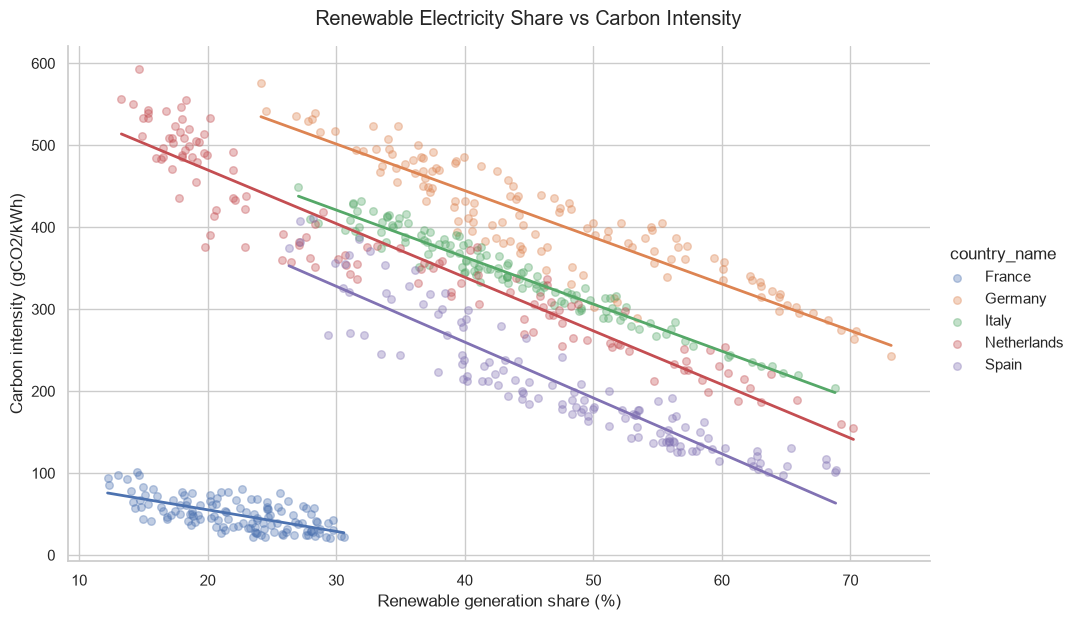

In [12]:
renewable_intensity_plot = sns.lmplot(
    data=comparison_data,
    x="renewable_share_pct",
    y="carbon_intensity_gco2_per_kwh",
    hue="country_name",
    height=6,
    aspect=1.6,
    scatter_kws={
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "linewidth": 2
    },
    ci=None
)

renewable_intensity_plot.set_axis_labels(
    "Renewable generation share (%)",
    "Carbon intensity (gCO2/kWh)"
)

renewable_intensity_plot.fig.suptitle(
    "Renewable Electricity Share vs Carbon Intensity",
    y=1.03
)

plt.show()

### Country-level correlations

Pearson and Spearman correlations quantify the association between renewable electricity share and carbon intensity within each country.

In [13]:
correlation_rows = []

for country, country_data in comparison_data.groupby("country_name"):
    pearson_correlation = country_data[
        "renewable_share_pct"
    ].corr(
        country_data["carbon_intensity_gco2_per_kwh"],
        method="pearson"
    )

    spearman_correlation = country_data[
        "renewable_share_pct"
    ].corr(
        country_data["carbon_intensity_gco2_per_kwh"],
        method="spearman"
    )

    correlation_rows.append(
        {
            "country_name": country,
            "pearson_correlation": pearson_correlation,
            "spearman_correlation": spearman_correlation
        }
    )

correlation_by_country = (
    pd.DataFrame(correlation_rows)
    .round(3)
    .sort_values("pearson_correlation")
    .reset_index(drop=True)
)

display(correlation_by_country)

,country_name,pearson_correlation,spearman_correlation
0,Italy,-0.972,-0.964
1,Netherlands,-0.953,-0.965
2,Spain,-0.926,-0.960
3,Germany,-0.911,-0.911
4,France,-0.647,-0.622


#### Renewable-correlation findings

- Renewable share had a negative correlation with carbon intensity in every country.
- Italy showed the strongest Pearson correlation (-0.972), followed by the Netherlands (-0.953), Spain (-0.926) and Germany (-0.911).
- France showed a weaker but still negative relationship (-0.647), partly because nuclear generation already keeps its carbon intensity very low.
- These results support an inverse association between renewable electricity and carbon intensity, but they do not establish causation.

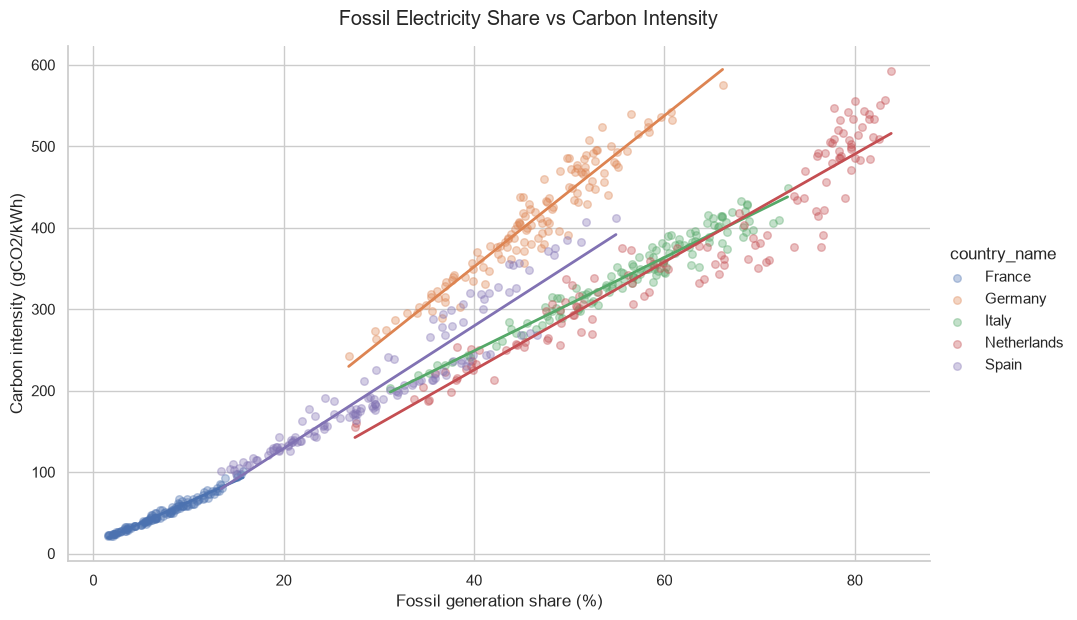

In [14]:
fossil_intensity_plot = sns.lmplot(
    data=comparison_data,
    x="fossil_share_pct",
    y="carbon_intensity_gco2_per_kwh",
    hue="country_name",
    height=6,
    aspect=1.6,
    scatter_kws={
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "linewidth": 2
    },
    ci=None
)

fossil_intensity_plot.set_axis_labels(
    "Fossil generation share (%)",
    "Carbon intensity (gCO2/kWh)"
)

fossil_intensity_plot.fig.suptitle(
    "Fossil Electricity Share vs Carbon Intensity",
    y=1.03
)

plt.show()

#### Fossil-share findings

- Fossil electricity share has a clear positive association with carbon intensity in all five countries.
- Country-months with greater fossil-fuel dependence generally produce more CO2 per unit of electricity.
- France combines a very low fossil share with consistently low carbon intensity.
- Differences between country-level lines suggest that the composition of fossil generation, such as coal versus gas, may also influence carbon intensity.
- This relationship is observational and does not independently establish causation.

In [15]:
fossil_correlation_rows = []

for country, country_data in comparison_data.groupby("country_name"):
    pearson_correlation = country_data[
        "fossil_share_pct"
    ].corr(
        country_data["carbon_intensity_gco2_per_kwh"],
        method="pearson"
    )

    spearman_correlation = country_data[
        "fossil_share_pct"
    ].corr(
        country_data["carbon_intensity_gco2_per_kwh"],
        method="spearman"
    )

    fossil_correlation_rows.append(
        {
            "country_name": country,
            "pearson_correlation": pearson_correlation,
            "spearman_correlation": spearman_correlation
        }
    )

fossil_correlation_by_country = (
    pd.DataFrame(fossil_correlation_rows)
    .round(3)
    .sort_values("pearson_correlation", ascending=False)
    .reset_index(drop=True)
)

display(fossil_correlation_by_country)

,country_name,pearson_correlation,spearman_correlation
0,France,0.987,0.990
1,Italy,0.972,0.964
2,Germany,0.959,0.948
3,Netherlands,0.956,0.967
4,Spain,0.953,0.976


#### Fossil-correlation findings

Fossil electricity share had a very strong positive correlation with carbon intensity in every country, with Pearson correlations ranging from +0.953 to +0.987. This provides strong evidence that greater fossil-fuel dependence is associated with more carbon-intensive electricity.

## 6. Seasonal electricity patterns

### Seasonal electricity demand

Average demand is calculated for each calendar month using the complete years 2016–2025. The incomplete 2026 calendar year is excluded to prevent January–July from receiving an additional observation.

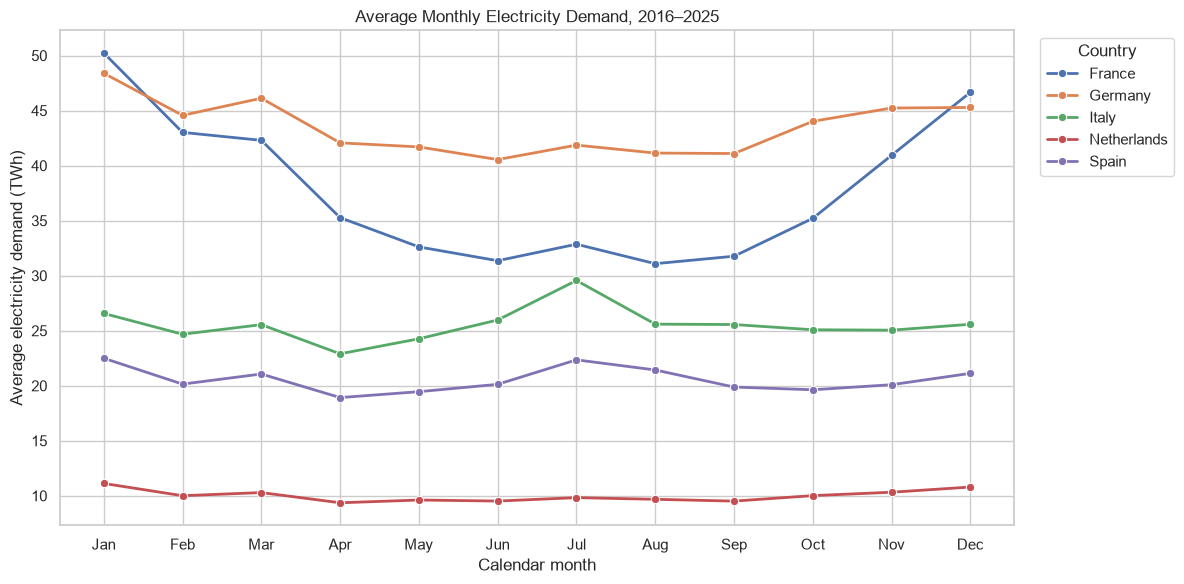

In [16]:
seasonal_data = comparison_data.loc[
    comparison_data["month"].dt.year.between(2016, 2025)
].copy()

seasonal_data["calendar_month"] = (
    seasonal_data["month"].dt.month
)

seasonal_demand = (
    seasonal_data
    .groupby(
        ["country_name", "calendar_month"],
        as_index=False
    )
    .agg(
        average_demand_twh=("demand_twh", "mean")
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=seasonal_demand,
    x="calendar_month",
    y="average_demand_twh",
    hue="country_name",
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Electricity Demand, 2016–2025")
plt.xlabel("Calendar month")
plt.ylabel("Average electricity demand (TWh)")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.legend(title="Country", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

#### Seasonal-demand findings

- France exhibits the strongest seasonal variation, with electricity demand peaking in winter and reaching its lowest levels during summer.
- Germany maintains relatively high demand throughout the year, with a moderate summer decline.
- Italy shows a noticeable July peak, consistent with increased summer cooling requirements.
- Spain displays both winter and summer demand peaks.
- The Netherlands shows a smaller but visible winter increase.
- Absolute electricity demand is influenced by country size and should not be interpreted as a measure of energy efficiency.

### Seasonal carbon intensity

We calculate average carbon intensity for each calendar month to determine whether electricity becomes cleaner or more carbon-intensive during particular seasons.

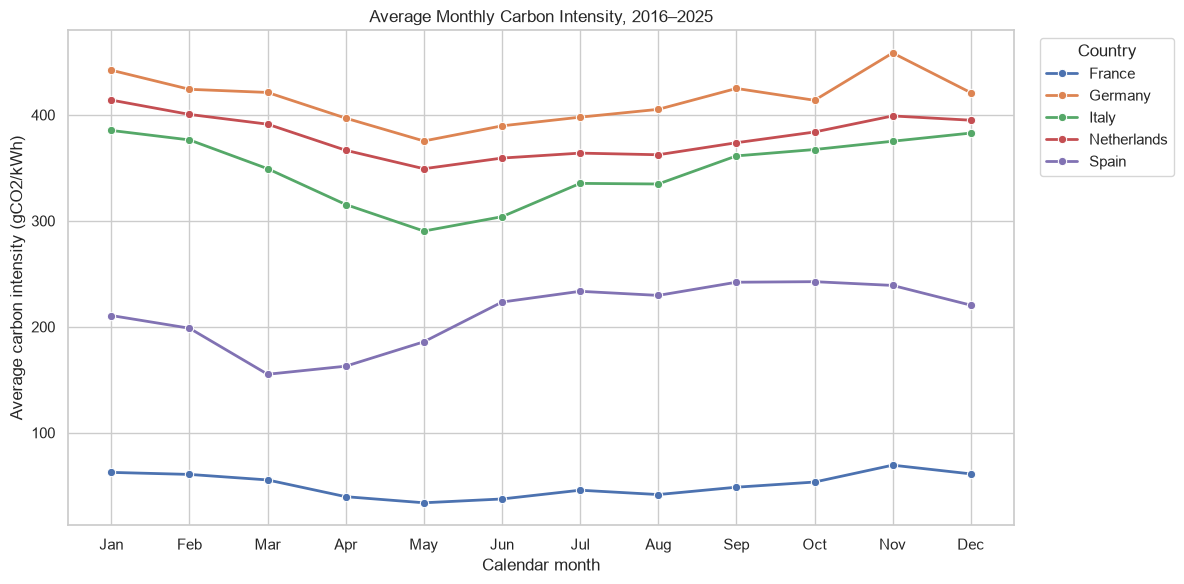

In [17]:
seasonal_carbon_intensity = (
    seasonal_data
    .groupby(
        ["country_name", "calendar_month"],
        as_index=False
    )
    .agg(
        average_carbon_intensity=(
            "carbon_intensity_gco2_per_kwh",
            "mean"
        )
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=seasonal_carbon_intensity,
    x="calendar_month",
    y="average_carbon_intensity",
    hue="country_name",
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Carbon Intensity, 2016–2025")
plt.xlabel("Calendar month")
plt.ylabel("Average carbon intensity (gCO2/kWh)")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.legend(title="Country", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

#### Seasonal carbon-intensity findings

- Germany recorded the highest average carbon intensity throughout the calendar year, with its highest level occurring around November.
- Italy and the Netherlands were generally cleaner during spring and more carbon-intensive during winter.
- Spain reached its lowest average carbon intensity around March and its highest levels during late summer and autumn.
- France remained substantially less carbon-intensive than the other countries during every month.
- The results indicate clear seasonal variation, although additional generation-source analysis would be required to identify the exact causes.

## 7. Electricity import dependence

We compare average net imports and count how frequently each country operated as a net importer or net exporter during the common analysis period.

In [18]:
import_dependence_summary = (
    comparison_data.groupby("country_name", as_index=False)
    .agg(
        observations=("month", "size"),
        average_net_imports_twh=("net_imports_twh", "mean"),
        average_import_dependence_pct=(
            "net_import_dependence_pct",
            "mean"
        ),
        net_importer_months=(
            "net_imports_twh",
            lambda values: (values > 0).sum()
        ),
        net_exporter_months=(
            "net_imports_twh",
            lambda values: (values < 0).sum()
        )
    )
)

import_dependence_summary["exporter_month_share_pct"] = (
    import_dependence_summary["net_exporter_months"]
    / import_dependence_summary["observations"]
    * 100
)

import_dependence_summary = (
    import_dependence_summary
    .round(2)
    .sort_values(
        "average_import_dependence_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

display(import_dependence_summary)

,country_name,observations,average_net_imports_twh,average_import_dependence_pct,net_importer_months,net_exporter_months,exporter_month_share_pct
0,Italy,127,3.58,14.00,127,0,0.00
1,Spain,127,-0.21,-1.12,56,71,55.91
2,Netherlands,127,-0.18,-1.70,52,75,59.06
3,Germany,127,-1.59,-3.27,39,88,69.29
4,France,127,-4.35,-12.30,16,111,87.40


#### Import-dependence findings

- Italy was a net electricity importer during all 127 months, with average import dependence of 14%.
- France was the strongest and most consistent exporter, recording net exports during 87.4% of months.
- Germany was a net exporter during 69.29% of months.
- The Netherlands and Spain moved between importing and exporting, but both operated as net exporters slightly more frequently.
- Import dependence describes cross-border electricity balance and should not automatically be interpreted as good or bad.

### Import dependence over time

A 12-month rolling average is used to show when countries moved between net-importing and net-exporting positions.

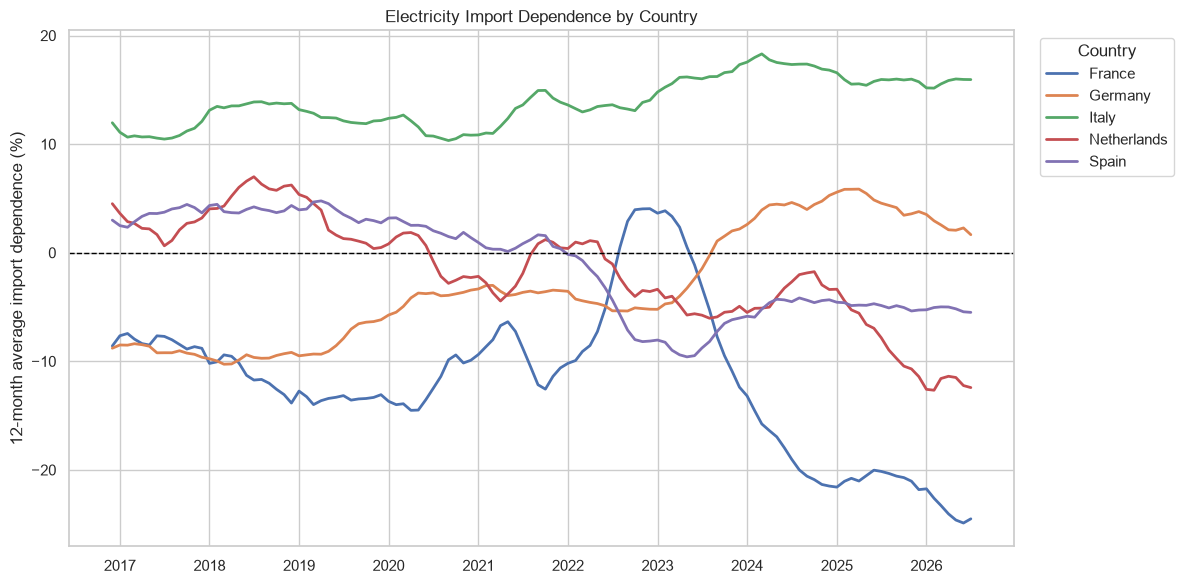

In [19]:
comparison_data["import_dependence_12m_avg"] = (
    comparison_data.groupby("country_name")[
        "net_import_dependence_pct"
    ]
    .transform(
        lambda values: values.rolling(
            window=12,
            min_periods=12
        ).mean()
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=comparison_data,
    x="month",
    y="import_dependence_12m_avg",
    hue="country_name",
    linewidth=2
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Electricity Import Dependence by Country")
plt.xlabel("")
plt.ylabel("12-month average import dependence (%)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

#### Import-dependence trend findings

- Italy remained a net electricity importer throughout the analysis period, with import dependence increasing after 2022.
- France was usually a strong exporter, except for a temporary importing period around 2022–2023.
- Germany moved from a net-exporting position to net importing around late 2023.
- The Netherlands transitioned from importing toward exporting around 2020 and became a stronger exporter after 2024.
- Spain moved into a net-exporting position around 2022 and remained there.

## 8. Total power-sector emissions

Carbon intensity measures emissions per unit of electricity, whereas total emissions measure the complete amount emitted. A 12-month rolling average is used to examine long-term emissions trends. The comparison ends in June 2026 because Italy's July 2026 emissions are unavailable.

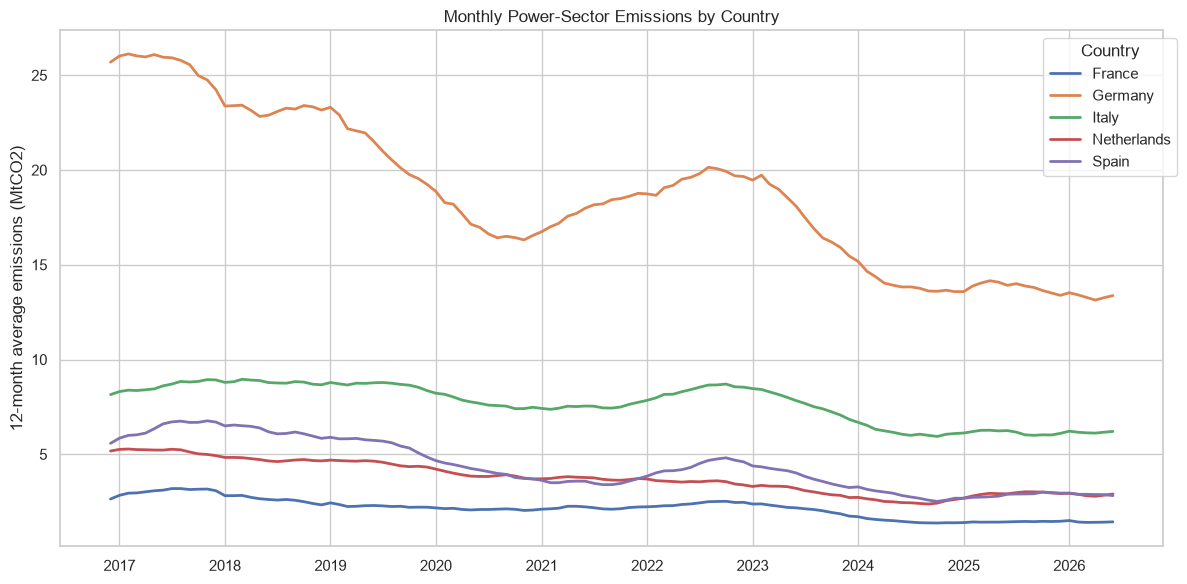

In [20]:
emissions_data = comparison_data.loc[
    (comparison_data["month"] <= "2026-06-01")
    & comparison_data["total_emissions_mtco2"].notna()
].copy()

emissions_data["total_emissions_12m_avg"] = (
    emissions_data.groupby("country_name")[
        "total_emissions_mtco2"
    ]
    .transform(
        lambda values: values.rolling(
            window=12,
            min_periods=12
        ).mean()
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=emissions_data,
    x="month",
    y="total_emissions_12m_avg",
    hue="country_name",
    linewidth=2
)

plt.title("Monthly Power-Sector Emissions by Country")
plt.xlabel("")
plt.ylabel("12-month average emissions (MtCO2)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

#### Total-emissions findings

- Total power-sector emissions declined across all five countries over the analysis period.
- Germany remained the largest emitter but achieved a substantial overall reduction.
- Spain, France and the Netherlands also recorded strong downward trends.
- Italy's emissions declined more moderately.
- Several countries experienced a temporary emissions rebound around 2021–2023 before reductions resumed.
- France maintained low total emissions despite relatively high electricity demand, reflecting its low-fossil, nuclear-heavy electricity mix.

In [21]:
import statsmodels.formula.api as smf

## 9. Statistical modelling

### Multiple linear regression

A multiple linear regression examines whether renewable and nuclear electricity shares remain associated with carbon intensity after controlling for country differences, calendar-month seasonality and the long-term time trend.

Because renewable, fossil and nuclear shares sum to approximately 100%, fossil share is omitted and treated as the reference category. The renewable and nuclear coefficients therefore represent replacing fossil generation with those lower-carbon sources.

The model estimates controlled associations and should not be interpreted as definitive causal evidence.

In [22]:
import statsmodels.formula.api as smf

regression_data = seasonal_data.copy()

regression_data["time_index"] = (
    (regression_data["month"].dt.year - 2016) * 12
    + regression_data["month"].dt.month
    - 1
)

regression_model = smf.ols(
    formula=(
        "carbon_intensity_gco2_per_kwh ~ "
        "renewable_share_pct + "
        "nuclear_share_pct + "
        "C(country_name) + "
        "C(calendar_month) + "
        "time_index"
    ),
    data=regression_data
).fit()

print(regression_model.summary())

                                  OLS Regression Results                                 
Dep. Variable:     carbon_intensity_gco2_per_kwh   R-squared:                       0.980
Model:                                       OLS   Adj. R-squared:                  0.979
Method:                            Least Squares   F-statistic:                     1558.
Date:                           Sun, 06 Sep 2026   Prob (F-statistic):               0.00
Time:                                   23:07:46   Log-Likelihood:                -2695.9
No. Observations:                            600   AIC:                             5430.
Df Residuals:                                581   BIC:                             5513.
Df Model:                                     18                                         
Covariance Type:                       nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-

#### Regression findings and limitations

- The model explained approximately 98% of the observed variation in carbon intensity.
- Replacing one percentage point of fossil generation with renewable generation was associated with approximately 6.51 gCO2/kWh lower carbon intensity.
- Replacing one percentage point of fossil generation with nuclear generation was associated with approximately 5.77 gCO2/kWh lower carbon intensity.
- Both coefficients were statistically significant under the standard OLS assumptions.
- Carbon intensity also showed an estimated controlled decline of approximately 0.23 gCO2/kWh per month.
- Most calendar-month effects were not statistically significant after controlling for the electricity mix, country and time trend.
- The low Durbin-Watson statistic (0.323) indicates strong positive autocorrelation. Therefore, the default non-robust standard errors and p-values should not be treated as final.
- The results represent controlled associations rather than definitive causal effects.

In [23]:
robust_regression_data = (
    regression_data
    .sort_values(["time_index", "country_name"])
    .reset_index(drop=True)
)

robust_model = smf.ols(
    formula=(
        "carbon_intensity_gco2_per_kwh ~ "
        "renewable_share_pct + "
        "nuclear_share_pct + "
        "C(country_name) + "
        "C(calendar_month) + "
        "time_index"
    ),
    data=robust_regression_data
).fit(
    cov_type="hac-groupsum",
    cov_kwds={
        "time": robust_regression_data["time_index"].to_numpy(),
        "maxlags": 12
    }
)

print(robust_model.summary())

                                  OLS Regression Results                                 
Dep. Variable:     carbon_intensity_gco2_per_kwh   R-squared:                       0.980
Model:                                       OLS   Adj. R-squared:                  0.979
Method:                            Least Squares   F-statistic:                     2235.
Date:                           Sun, 06 Sep 2026   Prob (F-statistic):                nan
Time:                                   23:07:46   Log-Likelihood:                -2695.9
No. Observations:                            600   AIC:                             5430.
Df Residuals:                                581   BIC:                             5513.
Df Model:                                     18                                         
Covariance Type:                    hac-groupsum                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-

## 7. Drivers of total power-sector emissions

This model examines how domestic electricity generation and the generation mix are associated with total monthly power-sector emissions. Country differences, calendar-month seasonality and the long-term time trend are controlled for.

In [24]:
emissions_regression_data = (
    regression_data
    .sort_values(["time_index", "country_name"])
    .reset_index(drop=True)
)

emissions_model = smf.ols(
    formula=(
        "total_emissions_mtco2 ~ "
        "domestic_generation_twh + "
        "renewable_share_pct + "
        "nuclear_share_pct + "
        "C(country_name) + "
        "C(calendar_month) + "
        "time_index"
    ),
    data=emissions_regression_data
).fit(
    cov_type="hac-groupsum",
    cov_kwds={
        "time": emissions_regression_data["time_index"].to_numpy(),
        "maxlags": 12
    }
)

print(emissions_model.summary())

                              OLS Regression Results                             
Dep. Variable:     total_emissions_mtco2   R-squared:                       0.954
Model:                               OLS   Adj. R-squared:                  0.953
Method:                    Least Squares   F-statistic:                     2482.
Date:                   Sun, 06 Sep 2026   Prob (F-statistic):                nan
Time:                           23:07:46   Log-Likelihood:                -1054.7
No. Observations:                    600   AIC:                             2149.
Df Residuals:                        580   BIC:                             2237.
Df Model:                             19                                         
Covariance Type:            hac-groupsum                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

#### Total-emissions regression finding

Domestic electricity generation was positively associated with total power-sector emissions. Holding generation volume constant, replacing one percentage point of fossil generation with renewable generation was associated with approximately 0.121 MtCO2 lower monthly emissions. The separate nuclear-share coefficient was not statistically significant after controlling for country, season and time, which should not be interpreted as evidence that nuclear generation increases emissions. The model describes controlled historical associations rather than causal effects.

In [25]:
train_data = regression_data.loc[
    regression_data["month"] < "2024-01-01"
].copy()

test_data = regression_data.loc[
    regression_data["month"] >= "2024-01-01"
].copy()

temporal_model = smf.ols(
    formula=(
        "carbon_intensity_gco2_per_kwh ~ "
        "renewable_share_pct + "
        "nuclear_share_pct + "
        "C(country_name) + "
        "C(calendar_month) + "
        "time_index"
    ),
    data=train_data
).fit()

print(
    "Training:",
    train_data["month"].min(),
    "to",
    train_data["month"].max(),
    train_data.shape
)

print(
    "Testing:",
    test_data["month"].min(),
    "to",
    test_data["month"].max(),
    test_data.shape
)

Training: 2016-01-01 00:00:00 to 2023-12-01 00:00:00 (480, 24)
Testing: 2024-01-01 00:00:00 to 2025-12-01 00:00:00 (120, 24)


In [26]:
train_data["predicted_carbon_intensity"] = temporal_model.predict(
    train_data
)

test_data["predicted_carbon_intensity"] = temporal_model.predict(
    test_data
)

In [27]:
import numpy as np
def calculate_regression_metrics(actual, predicted):
    errors = actual - predicted

    mae = errors.abs().mean()

    rmse = np.sqrt(
        (errors ** 2).mean()
    )

    r_squared = 1 - (
        (errors ** 2).sum()
        / ((actual - actual.mean()) ** 2).sum()
    )

    return pd.Series({
        "r_squared": r_squared,
        "mae_gco2_per_kwh": mae,
        "rmse_gco2_per_kwh": rmse
    })


temporal_performance = pd.DataFrame({
    "Training": calculate_regression_metrics(
        train_data["carbon_intensity_gco2_per_kwh"],
        train_data["predicted_carbon_intensity"]
    ),
    "Testing": calculate_regression_metrics(
        test_data["carbon_intensity_gco2_per_kwh"],
        test_data["predicted_carbon_intensity"]
    )
}).T.round(3)

display(temporal_performance)

,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
Training,0.979,16.645,22.374
Testing,0.960,21.094,24.006


#### Temporal validation result

The regression was trained on observations from 2016–2023 and evaluated on the unseen 2024–2025 period. Training R² was 0.979 and testing R² was 0.960, indicating only a small deterioration in explanatory performance. Testing MAE was approximately 21.09 gCO2/kWh and testing RMSE was approximately 24.01 gCO2/kWh. The results provide no strong evidence of overfitting and indicate that the relationship between electricity mix and carbon intensity remained stable in the later period. Because contemporaneous generation shares were supplied to the model, this represents temporal validation of the relationship rather than a complete future forecast.

In [28]:
country_results = []

for country_name, country_data in test_data.groupby("country_name"):
    actual = country_data["carbon_intensity_gco2_per_kwh"]
    predicted = country_data["predicted_carbon_intensity"]

    errors = actual - predicted

    mae = errors.abs().mean()

    rmse = np.sqrt(
        (errors ** 2).mean()
    )

    r_squared = 1 - (
        (errors ** 2).sum()
        / ((actual - actual.mean()) ** 2).sum()
    )

    mean_error = errors.mean()

    country_results.append({
        "country_name": country_name,
        "test_observations": len(country_data),
        "r_squared": r_squared,
        "mae_gco2_per_kwh": mae,
        "rmse_gco2_per_kwh": rmse,
        "mean_error_gco2_per_kwh": mean_error
    })


country_performance = (
    pd.DataFrame(country_results)
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
)

numeric_columns = country_performance.select_dtypes(
    include="number"
).columns

country_performance[numeric_columns] = (
    country_performance[numeric_columns].round(3)
)

display(country_performance)

,country_name,test_observations,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh,mean_error_gco2_per_kwh
0,Spain,24,0.623,12.356,13.923,11.760
1,Germany,24,0.827,18.007,20.144,-17.878
2,Italy,24,0.727,19.466,23.887,18.119
3,Netherlands,24,0.719,27.012,29.546,26.288
4,France,24,-9.131,28.629,28.952,28.629


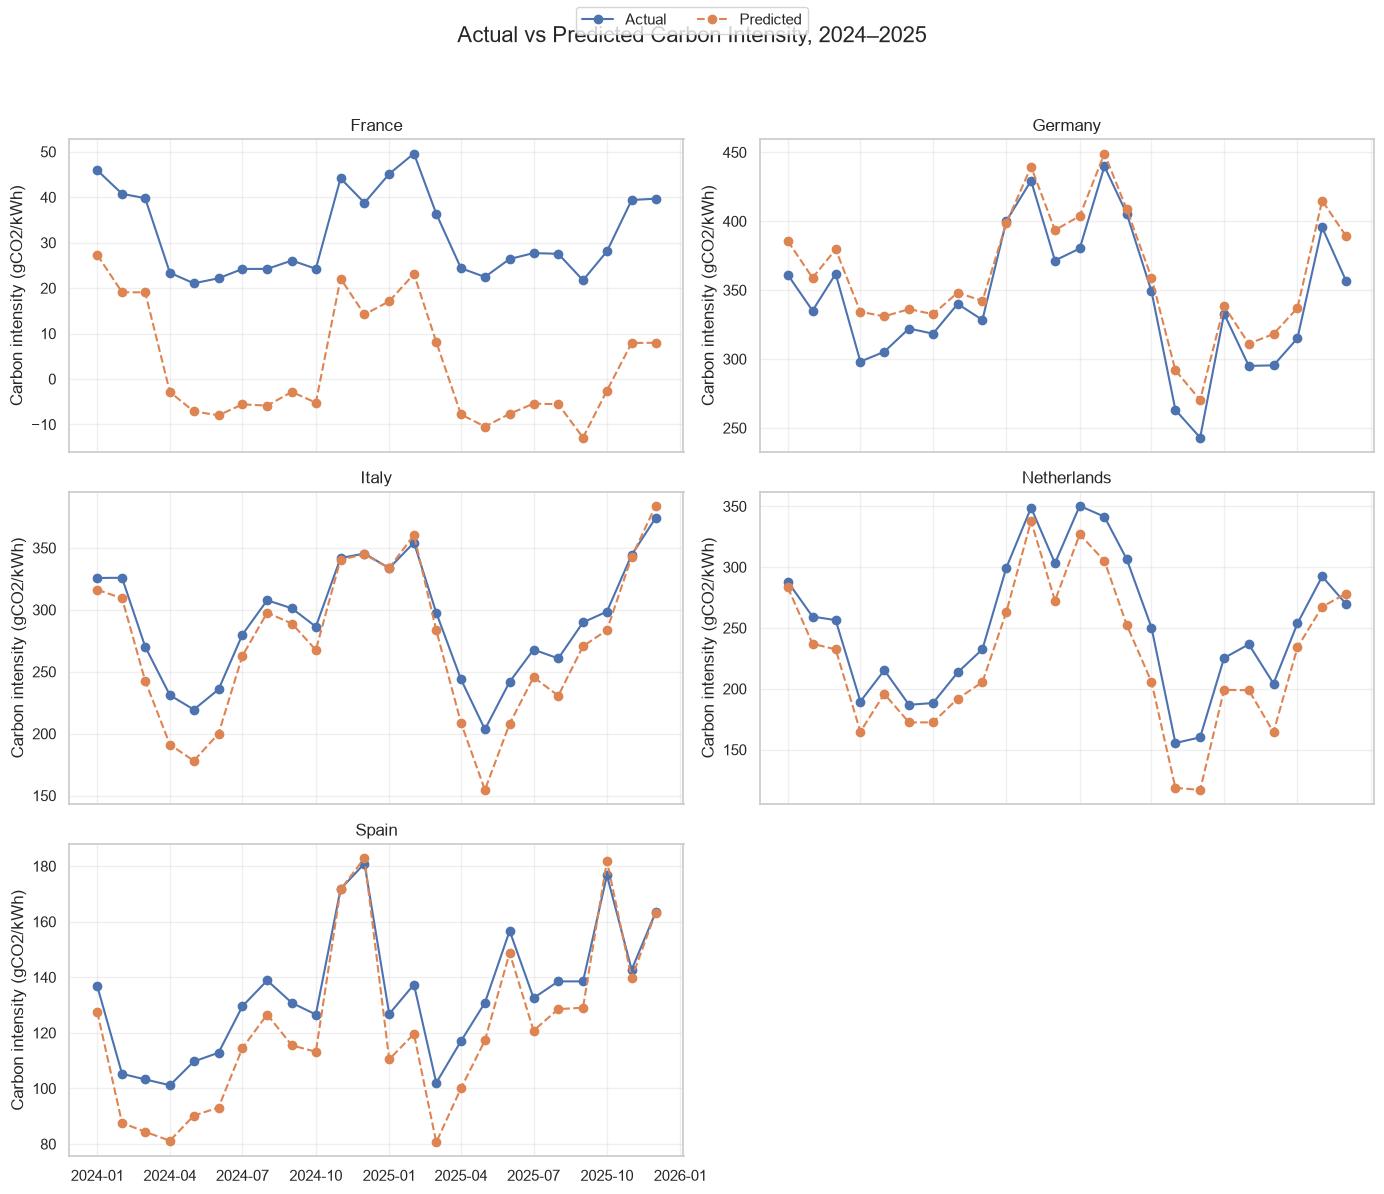

In [29]:
countries = sorted(
    test_data["country_name"].unique()
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12),
    sharex=True
)

axes = axes.flatten()

for axis, country_name in zip(axes, countries):
    country_test = (
        test_data.loc[
            test_data["country_name"] == country_name
        ]
        .sort_values("month")
    )

    axis.plot(
        country_test["month"],
        country_test["carbon_intensity_gco2_per_kwh"],
        marker="o",
        label="Actual"
    )

    axis.plot(
        country_test["month"],
        country_test["predicted_carbon_intensity"],
        marker="o",
        linestyle="--",
        label="Predicted"
    )

    axis.set_title(country_name)
    axis.set_ylabel("Carbon intensity (gCO2/kWh)")
    axis.grid(alpha=0.3)


for unused_axis in axes[len(countries):]:
    unused_axis.set_visible(False)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

fig.suptitle(
    "Actual vs Predicted Carbon Intensity, 2024–2025",
    fontsize=16
)

fig.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

#### Country-level temporal validation

The combined test R² of 0.960 concealed substantial differences between countries. The model followed the general monthly pattern reasonably well for Germany, Italy, the Netherlands and Spain, but showed systematic prediction bias. It generally overpredicted Germany and underpredicted the other countries.

France performed particularly poorly, with a country-level R² of -9.131 and an average underprediction of approximately 28.63 gCO2/kWh. Some French predictions were negative, demonstrating that unconstrained linear regression can produce physically impossible values.

These results indicate that one pooled equation with common electricity-mix and time coefficients is insufficient to represent every national electricity system. Because the 2024–2025 test period has now been inspected, it will not be used for informal model tuning. Country-specific relationships and constrained predictions will instead be addressed using a separate validation design during the predictive-modelling stage.

## 10. Conclusions and limitations

### Main conclusion

Across the five examined European countries, the transition away from fossil electricity was strongly associated with lower carbon intensity. The relationship remained statistically significant after controlling for country differences, calendar-month seasonality, the long-term time trend and dependence between monthly observations.

The robust regression estimated that replacing one percentage point of fossil generation with renewable generation was associated with approximately 6.51 gCO2/kWh lower carbon intensity. Replacing one percentage point of fossil generation with nuclear generation was associated with approximately 5.77 gCO2/kWh lower carbon intensity.

### Country findings

- The Netherlands recorded the largest renewable-share increase, approximately 37.82 percentage points, and a 53.20% reduction in carbon intensity.
- Germany also achieved substantial renewable growth, although its fossil dependence kept carbon intensity comparatively high.
- Spain combined relatively high renewable generation with substantial carbon-intensity reduction.
- Italy increased its renewable share, but recorded the smallest carbon-intensity reduction among the five countries and remained a net electricity importer throughout the comparable period.
- France maintained the lowest carbon intensity because of its nuclear-dominated electricity system, despite having the lowest average renewable share.

These differences demonstrate that renewable share alone does not determine electricity-sector performance. Nuclear generation, fossil-fuel composition, production volume, cross-border electricity trade and national energy structures also matter.

### Total-emissions findings

Domestic electricity generation was positively associated with total power-sector emissions. Holding generation volume constant, replacing one percentage point of fossil generation with renewable generation was associated with approximately 0.121 MtCO2 lower monthly emissions.

The separate nuclear-share coefficient was not statistically significant in the total-emissions model after controlling for country, season and time. This should not be interpreted as evidence that nuclear generation increases emissions.

### Temporal validation

The carbon-intensity regression achieved a training R² of 0.979 and a combined testing R² of 0.960 on the unseen 2024–2025 period. However, country-level evaluation revealed systematic prediction bias and particularly poor performance for France.

The model therefore provides strong evidence of a stable pooled historical relationship, but one common equation is not sufficient for accurate prediction in every national electricity system.

### Limitations

- The analysis is observational and does not establish definitive causal effects.
- Carbon intensity is structurally related to generation composition, which partly explains the high model R².
- Only five European countries were included, so the findings should not be generalized automatically to all European electricity systems.
- Broad renewable, fossil and nuclear categories conceal differences between individual technologies and fuels.
- Italy begins in January 2016, while the other countries begin in January 2015.
- Italian emissions for July 2026 were unavailable and were retained as missing rather than incorrectly replaced with zero.
- Linear regression can generate physically impossible negative predictions and cannot represent every nonlinear or country-specific relationship.
- The temporal test used contemporaneous generation shares, so it validates relationship stability rather than providing a complete future forecast.